# Module Metrics
Load canonical evaluation methods for grid scales, orientations, and module grouping.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from src.evaluation import (
    module_index_by_sorted_score,
    get_grid_scales_cm,
    get_grid_orientations_deg,
    summarize_by_module,
    plot_sac_examples_with_scale_orientation,
)


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from pathlib import Path
import sys
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.visualize import compute_grid_metrics

RESULTS_DIR = PROJECT_ROOT / "results" / "tpc"
FIG_DIR = PROJECT_ROOT / "results" / "modules"

## Impact of having both separate inf lrs and blockwise Wr

In [4]:
from scipy.stats import mannwhitneyu, kruskal
runs_dt = [
    "Apr-05-2026-21-45-46",  # both: diff inf_lr + block wr
    "Apr-11-2026-20-05-03",  # diff inf_lr only
    "Apr-12-2026-09-50-39",  # block wr only
]

n_cells = 64
cell_rows = []
run_stats = []

def p_to_stars(p):
    if not np.isfinite(p): return "n/a"
    if p < 1e-3: return "***"
    if p < 1e-2: return "**"
    if p < 5e-2: return "*"
    return "ns"

for dt in runs_dt:
    path = f'../results/tpc/{dt}'
    mod_idx, cfg = module_index_by_sorted_score(path, n_cells=n_cells)

    # use env height from config for cm conversion
    h = float(cfg.get("box_height", 1.6))
    scales_cm, scales_px, *_ = get_grid_scales_cm(dt, model='tpc', n_cells=n_cells)
    print(scales_px.max(), scales_px.min(), scales_px.mean())

    valid = np.isfinite(scales_cm)
    scales = scales_cm[valid]
    mods = mod_idx[valid]

    inf_lr = cfg.get("inf_lr", [])
    inf_lr_u = np.unique(np.asarray(inf_lr, dtype=float)) if isinstance(inf_lr, list) else np.array([inf_lr], dtype=float)
    diff_inf = len(inf_lr_u) > 1
    block_wr = bool(cfg.get("wr_block_diag", False))

    if diff_inf and block_wr: condition = r"Diff $\tau_g$ + Block $W$"
    elif diff_inf and (not block_wr): condition = r"Diff $\tau_g$ only"
    elif (not diff_inf) and block_wr: condition = r"Block $W$ only"
    else: condition = "neither"

    for s, m in zip(scales, mods):
        cell_rows.append({
            "run": dt,
            "module": int(m),
            "scale_cm": float(s),
            "condition": condition,
            "block_wr": block_wr,
            "diff_inf": diff_inf
        })

    groups = [scales[mods == m] for m in sorted(np.unique(mods))]
    groups = [g for g in groups if len(g) > 1]

    if len(groups) == 2:
        test = "Mann-Whitney U"
        stat, p = mannwhitneyu(groups[0], groups[1], alternative="two-sided")
    elif len(groups) > 2:
        test = "Kruskal-Wallis"
        stat, p = kruskal(*groups)
    else:
        test, stat, p = "NA", np.nan, np.nan

    run_stats.append({
        "run": dt, "condition": condition, "test": test, "stat": stat, "p": p, "sig": p_to_stars(p)
    })

cell_df = pd.DataFrame(cell_rows)
stats_df = pd.DataFrame(run_stats).sort_values("run")
summary_df = (
    cell_df.groupby(["run", "condition", "module"], as_index=False)["scale_cm"]
    .agg(mean="mean", std="std", n="count")
)

display(stats_df)
display(summary_df.head(10))

9.706284379915772 6.575893185923203 8.075802310178947
10.545619687260624 7.275625218930629 8.306434285010312
10.72063439780482 6.599582456545028 8.063487987107916


,run,condition,test,stat,p,sig
0,Apr-05-2026-21-45-46,Diff $\tau_g$ + Block $W$,Mann-Whitney U,123.0,0.000003,***
1,Apr-11-2026-20-05-03,Diff $\tau_g$ only,Mann-Whitney U,336.5,0.023773,*
2,Apr-12-2026-09-50-39,Block $W$ only,Mann-Whitney U,314.5,0.139313,ns


,run,condition,module,mean,std,n
0,Apr-05-2026-21-45-46,Diff $\tau_g$ + Block $W$,0,62.087671,5.290964,43
1,Apr-05-2026-21-45-46,Diff $\tau_g$ + Block $W$,1,69.763855,4.346897,21
2,Apr-11-2026-20-05-03,Diff $\tau_g$ only,0,64.897589,3.958415,28
3,Apr-11-2026-20-05-03,Diff $\tau_g$ only,1,67.660052,5.130225,36
4,Apr-12-2026-09-50-39,Block $W$ only,0,63.482354,6.185680,46
5,Apr-12-2026-09-50-39,Block $W$ only,1,67.128754,7.605725,18


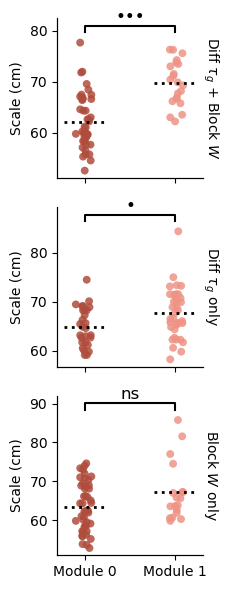

In [6]:
def plot_run_module_jitter_panel(cell_df, stats_df, runs_dt, dot_mode="levels"):
    """
    Plot multiple runs as stacked jitter plots with modules on x and scale on y.
    Per-cell scale jitter by module + module mean + significance bracket.
    """
    import numpy as np
    import matplotlib.pyplot as plt

    def p_to_mark(pv):
        if not np.isfinite(pv):
            return "•"
        if dot_mode == "single":
            return "•" if pv < 0.05 else "ns"
        if pv < 1e-3:
            return "•••"
        if pv < 1e-2:
            return "••"
        if pv < 5e-2:
            return "•"
        return "ns"

    module_colors = {0: "#af4c3c", 1: "#ee9385"}

    fig, axes = plt.subplots(
        len(runs_dt),
        1,
        figsize=(2.4, 2. * len(runs_dt)),
        sharex=True,
        squeeze=False,
    )
    axes = axes[:, 0]

    for ax, run_id in zip(axes, runs_dt):
        sub = cell_df[cell_df["run"] == run_id].copy()
        if sub.empty:
            raise ValueError(f"Run not found in cell_df: {run_id}")

        st = stats_df[stats_df["run"] == run_id]
        if st.empty:
            raise ValueError(f"Run not found in stats_df: {run_id}")
        st = st.iloc[0]
        condition = st.get("condition", run_id)

        p = float(st["p"])
        mark = p_to_mark(p)

        mods = np.array(sorted(sub["module"].astype(int).unique()))
        x = np.arange(len(mods))
        means = np.array([
            sub.loc[sub["module"] == m, "scale_cm"].mean()
            for m in mods
        ])

        rng = np.random.default_rng(0)

        for xi, m, mean in zip(x, mods, means):
            vals = sub.loc[sub["module"] == m, "scale_cm"].to_numpy(dtype=float)
            jitter = rng.normal(0, 0.045, size=len(vals))
            color = module_colors.get(int(m), "gray")

            ax.scatter(
                np.full(len(vals), xi) + jitter,
                vals,
                s=32,
                alpha=0.85,
                color=color,
                edgecolors="none",
            )

            ax.hlines(
                mean,
                xi - 0.24,
                xi + 0.24,
                color="black",
                lw=2,
                ls=":"
            )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        if len(x) >= 2:
            x1, x2 = x[0], x[-1]
            y_max = float(np.nanmax(sub["scale_cm"].to_numpy(dtype=float)))
            y_min = float(np.nanmin(sub["scale_cm"].to_numpy(dtype=float)))
            y_range = max(1.0, y_max - y_min)
            y_base = y_max + 0.08 * y_range
            h = 0.05 * y_range

            ax.plot(
                [x1, x1, x2, x2],
                [y_base, y_base + h, y_base + h, y_base],
                lw=1.5,
                c="black",
            )

            ax.text(
                (x1 + x2) / 2,
                y_base + 1.15 * h,
                mark,
                ha="center",
                va="bottom",
                fontsize=12,
            )
            ax.set_ylim(top=y_base + 2.2 * h)

        ax.set_xticks(x)
        ax.set_xticklabels([f"Module {int(m)}" for m in mods])

        ax_r = ax.twinx()
        ax_r.set_ylabel(condition, rotation=270, labelpad=12, fontsize=10)
        ax_r.set_yticks([])
        ax_r.spines["top"].set_visible(False)
        ax_r.spines["right"].set_visible(False)

    # axes[-1].set_xlabel("Module")
    for ax in axes:
        ax.set_ylabel("Scale (cm)")

    plt.tight_layout()
    plt.savefig(FIG_DIR / "module_scale_jitter_panel.pdf", bbox_inches="tight")
    plt.show()

    return fig, axes


fig, axes = plot_run_module_jitter_panel(
    cell_df,
    stats_df,
    runs_dt,
    dot_mode="levels",
)


## Single model visualizations

In [37]:
model = 'tpc'
dt = 'Apr-05-2026-21-45-46'
n_cells = 64

run_path = f'../results/{model}/{dt}'
assert os.path.exists(run_path), f'Run path not found: {run_path}'
run_path


'../results/tpc/Apr-05-2026-21-45-46'

In [38]:
rate_maps = np.load(os.path.join(run_path, f'grid_maps.npy'))

In [39]:
module_idx_sorted, cfg = module_index_by_sorted_score(run_path, n_cells=n_cells)

scales_cm, scales_px, scores, unsrt_scores, sacs = get_grid_scales_cm(
    dt=dt, model=model, n_cells=n_cells
)

orientations_deg, axes_deg, _, _, _ = get_grid_orientations_deg(
    dt=dt, model=model, n_cells=n_cells
)

print('Loaded cells:', len(scales_cm))
print('n_module:', cfg.get('n_module', 1), 'module_fracs:', cfg.get('module_fracs', None))


Loaded cells: 64
n_module: 2 module_fracs: [0.7, 0.3]


(array([0.01247847, 0.01247847, 0.03743542, 0.02495694, 0.06239236,
        0.09982778, 0.04991389, 0.02495694, 0.06239236, 0.03743542,
        0.02495694, 0.11230625, 0.03743542, 0.03743542, 0.02495694,
        0.03743542, 0.03743542, 0.01247847, 0.03743542, 0.01247847]),
 array([52.60714549, 53.85930196, 55.11145844, 56.36361492, 57.6157714 ,
        58.86792788, 60.12008435, 61.37224083, 62.62439731, 63.87655379,
        65.12871026, 66.38086674, 67.63302322, 68.8851797 , 70.13733617,
        71.38949265, 72.64164913, 73.89380561, 75.14596208, 76.39811856,
        77.65027504]),
 <BarContainer object of 20 artists>)

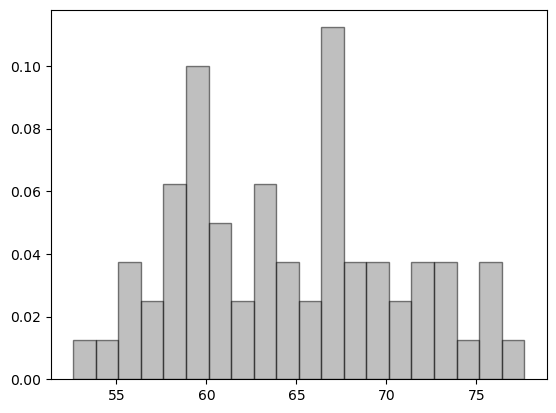

In [40]:
plt.hist(
    scales_cm,
    bins=20,
    density=True,
    alpha=0.5,
    color="gray",
    edgecolor="black",
)

In [41]:
import numpy as np
from sklearn.mixture import GaussianMixture

def fit_gmm_bic_scales(scale_cm, ks=(1, 2), log_scale=True, random_state=0):
    x = np.asarray(scale_cm, dtype=float)
    x = x[np.isfinite(x) & (x > 0)]

    if log_scale:
        x_fit = np.log(x).reshape(-1, 1)
    else:
        x_fit = x.reshape(-1, 1)

    rows = []
    gmms = {}

    for k in ks:
        gmm = GaussianMixture(
            n_components=k,
            covariance_type="full",
            random_state=random_state,
        )
        gmm.fit(x_fit)

        rows.append({
            "k": k,
            "bic": gmm.bic(x_fit),
            "aic": gmm.aic(x_fit),
        })
        gmms[k] = gmm

    return rows, gmms


rows, gmms = fit_gmm_bic_scales(scales_cm, ks=(1, 2, 3), log_scale=True)
rows

c:\Users\User\miniconda3\envs\dlenv\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\User\miniconda3\envs\dlenv\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\User\miniconda3\envs\dlenv\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


[{'k': 1, 'bic': -112.46010852198071, 'aic': -116.77787468870005},
 {'k': 2, 'bic': -104.69590118053979, 'aic': -115.49031659733815},
 {'k': 3, 'bic': -94.90141951840079, 'aic': -112.17248418527817}]

[0.7 0.3]
block mean |W|:
[[0.036439 0.      ]
 [0.       0.075888]]


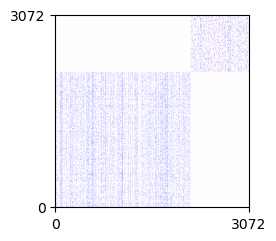

In [31]:
# plt weights of the model
import json
import numpy as np
import torch

# W is your recurrent weight matrix [Ng, Ng]
# run_dir is already defined
with open(f"{run_path}/configs.json", "r") as f:
    cfg = json.load(f)

n_module = int(cfg.get("n_module", 1))
fracs = np.asarray(cfg.get("module_fracs", [1.0]), dtype=float)
fracs = fracs / fracs.sum()
print(fracs)

ckpt = torch.load(f"{run_path}/models/most_recent_model.pth", map_location="cpu")

if model == 'tpc':
    Wr = ckpt["model"]["Wr.weight"].cpu().numpy()
    W = Wr  # [Ng, Ng]
elif model == 'rnn':
    Wr = ckpt["RNN.weight_hh_l0"].cpu().numpy()
    W = Wr  # [Ng, Ng]

Ng = W.shape[0]
counts = np.floor(fracs * Ng).astype(int)
counts[-1] = Ng - counts[:-1].sum()

starts = np.cumsum(np.r_[0, counts[:-1]])
ends = starts + counts

block_mean_abs = np.zeros((n_module, n_module))
for i in range(n_module):
    for j in range(n_module):
        block = W[starts[i]:ends[i], starts[j]:ends[j]]
        block_mean_abs[i, j] = np.mean(np.abs(block))

print("block mean |W|:")
print(np.round(block_mean_abs, 6))
# 1) Clip to robust percentile range (ignore extreme outliers)
p = 95
v = np.percentile(np.abs(W), p)

plt.figure(figsize=(2.5,2.5))
plt.imshow(np.clip(W, -v, v), cmap="seismic", vmin=-v, vmax=v, aspect="auto", origin="lower")
# plt.colorbar(label=f"Wr (clipped at ±P{p})")
# plt.title("Wr (robust clipped)")
plt.xticks([0, 3072])
plt.yticks([0, 3072])
# plt.tight_layout()
# plt.savefig(FIG_DIR / "module_Wr_clipped.pdf", bbox_inches="tight")
plt.show()

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def wrap_to_pm30_deg(a_deg):
    return ((np.asarray(a_deg, dtype=float) + 30.0) % 60.0) - 30.0

def _ecdf(x):
    x = np.sort(np.asarray(x, dtype=float))
    y = np.arange(1, x.size + 1) / x.size
    return x, y

def plot_orientation_hist_ecdf_overlay(
    orientations_deg,
    module_idx_sorted,
    modules=(0, 1),
    bins=18,
    xlim=(-30, 30),
    density=True,
):
    ori = np.asarray(orientations_deg, dtype=float)
    mod = np.asarray(module_idx_sorted, dtype=int)

    valid = np.isfinite(ori)
    ori = wrap_to_pm30_deg(ori[valid])
    mod = mod[valid]

    module_colors = {
        0: "#0072B2",  # blue
        1: "#D55E00",  # vermillion
        2: "#009E73",
        3: "#CC79A7",
    }

    fig, (ax_h, ax_e) = plt.subplots(
        2, 1, figsize=(7.2, 6.0), sharex=True,
        gridspec_kw={"height_ratios": [2.0, 1.2], "hspace": 0.08}
    )

    for i, m in enumerate(modules):
        x = ori[mod == m]
        if x.size == 0:
            continue
        color = module_colors.get(int(m), f"C{i}")

        # Histogram overlay
        ax_h.hist(
            x, bins=bins, range=xlim, density=density,
            alpha=0.25, color=color, linewidth=0.8,
            label=f"Module {m} hist (n={x.size})"
        )

        # ECDF overlay
        xe, ye = _ecdf(x)
        ax_e.step(xe, ye, where="post", color=color, lw=2.2, label=f"Module {m} ECDF")

    ax_h.set_ylabel("Density" if density else "Count")
    ax_h.set_title("Orientation Distribution by Module: Histogram + ECDF")
    ax_h.grid(alpha=0.2, linestyle="--")
    ax_h.spines["top"].set_visible(False)
    ax_h.spines["right"].set_visible(False)
    ax_h.legend(frameon=False)

    ax_e.set_xlim(*xlim)
    ax_e.set_ylim(0, 1.02)
    ax_e.set_xlabel("Orientation (deg), wrapped to [-30, 30)")
    ax_e.set_ylabel("ECDF")
    ax_e.grid(alpha=0.2, linestyle="--")
    ax_e.spines["top"].set_visible(False)
    ax_e.spines["right"].set_visible(False)
    ax_e.legend(frameon=False)

    plt.tight_layout()
    plt.show()


C:\Users\User\AppData\Local\Temp\ipykernel_51204\1706214842.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


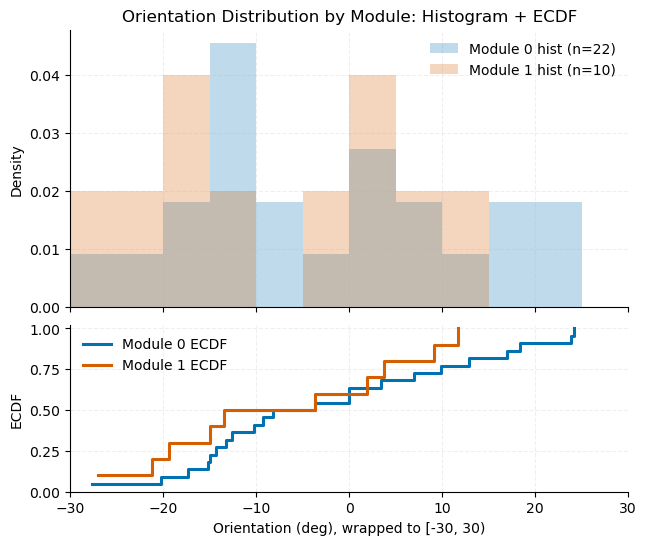

In [11]:
plot_orientation_hist_ecdf_overlay(
    orientations_deg=orientations_deg,
    module_idx_sorted=module_idx_sorted,
    modules=(0, 1),
    bins=12,
)


In [12]:
def plot_run_scales_scatter_hist_kde(
    dt,
    model="tpc",
    n_cells=64,
    k_max=6,
    prominence=0.15,
    grid_size=500,
    bw_mode="exp",
    exp_bw_a=0.5,
    exp_bw_b=0.01,
    exp_bw_min=0.02,
    exp_bw_max=1.0,
):
    import json
    import numpy as np
    import matplotlib.pyplot as plt
    from src.evaluation.module_eval import estimate_k_from_ksd

    path = f"../results/{model}/{dt}"

    # scales/scores in sorted-by-score order
    scales_cm, _, scores, unsrt_scores, _ = get_grid_scales_cm(
        dt, model=model, n_cells=n_cells
    )

    # module ids in sorted-by-score order
    cfg = json.load(open(f"{path}/configs.json", "r"))
    Ng = int(cfg["Ng"])
    n_module = int(cfg.get("n_module", 1))
    fracs = cfg.get("module_fracs", None)

    if fracs is None:
        counts = [Ng // n_module] * n_module
    else:
        fr = np.asarray(fracs, dtype=float)
        fr = fr / fr.sum()
        counts = np.floor(fr * Ng).astype(int)
        counts[-1] = Ng - counts[:-1].sum()
        counts = counts.tolist()

    sort_idx = np.argsort(unsrt_scores)[::-1]
    module_of_orig = np.empty(Ng, dtype=int)
    s = 0
    for m, c in enumerate(counts):
        module_of_orig[s:s+c] = m
        s += c
    module_idx_sorted = module_of_orig[sort_idx][:n_cells]

    # keep valid scales
    valid = np.isfinite(scales_cm) & (scales_cm > 0)
    scales = scales_cm[valid]
    mods = module_idx_sorted[valid]
    scs = scores[:n_cells][valid]

    # NEW: reorder x-axis by module, then by score within module
    order = np.lexsort((-scs, mods))
    scales_o = scales[order]
    mods_o = mods[order]
    x_o = np.arange(len(scales_o))

    # KDE/peaks from log-scales
    k_est, ksd = estimate_k_from_ksd(
        np.log(scales_o),
        k_max=k_max,
        prominence=prominence,
        grid_size=grid_size,
        bw_mode=bw_mode,
        exp_bw_a=exp_bw_a,
        exp_bw_b=exp_bw_b,
        exp_bw_min=exp_bw_min,
        exp_bw_max=exp_bw_max,
    )
    peak_log = ksd["grid"][ksd["peaks"]]
    peak_cm = np.exp(peak_log)

    # plot
    fig = plt.figure(figsize=(4.5, 3.5))
    gs = fig.add_gridspec(1, 2, width_ratios=[4, 1.4], wspace=0.05)
    ax_sc = fig.add_subplot(gs[0, 0])
    ax_hi = fig.add_subplot(gs[0, 1], sharey=ax_sc)

    # cmap = plt.cm.get_cmap("tab20", max(2, n_module))
    cmap = ['#af4c3c', '#ee9385']
    for m in np.unique(mods_o):
        msk = mods_o == m
        ax_sc.scatter(x_o[msk], scales_o[msk], s=16, alpha=0.85, color=cmap[int(m)], label=f"Module {int(m)}")

    # module boundaries
    boundaries = np.where(np.diff(mods_o) != 0)[0]
    for b in boundaries:
        ax_sc.axvline(b + 0.5, color="k", ls="--", lw=0.8, alpha=0.5)

    ax_sc.set_xlabel("Cell index")
    ax_sc.set_ylabel("Grid Scale (cm)")
    # ax_sc.set_title(f"{dt} | k_est={k_est}")
    ax_sc.legend(frameon=False, loc="best")
    ax_sc.grid(True, which="major", axis="both", alpha=0.25, linestyle="--")

    # rotated histogram + KDE (on scale axis)
    ax_hi.hist(scales_o, bins=13, orientation="horizontal", density=True, alpha=0.35, color="#c9958d")
    s_grid = np.linspace(scales_o.min(), scales_o.max(), 400)
    dens_s = np.interp(np.log(s_grid), ksd["grid"], ksd["density"]) / s_grid
    ax_hi.plot(dens_s, s_grid, color="#5c423e", lw=1.3)

    peak_dens = ksd["density"][ksd["peaks"]]   # density at each detected peak (log-space KDE)
    for p_cm, d_pk in zip(peak_cm, peak_dens):
        # ax_hi.axhline(p_cm, color="#372e2d", ls="--", lw=1, alpha=0.65)  # optional guide line
        ax_hi.plot([0, d_pk / p_cm], [p_cm, p_cm], color="#5c423e", ls="--", lw=1, alpha=0.65)

        ax_hi.plot(d_pk / p_cm, p_cm, "o", color="#5c423e", ms=5) 

    ax_hi.set_xlabel("Density")
    plt.setp(ax_hi.get_yticklabels(), visible=False)

    for ax in [ax_sc, ax_hi]:
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    plt.tight_layout()
    # plt.savefig(FIG_DIR / "module_scale_scatter_hist_kde.pdf", bbox_inches="tight")
    plt.show()

    return {
        "k_est": k_est,
        "peaks_cm": peak_cm,
        "ordered_scales_cm": scales_o,
        "ordered_modules": mods_o,
        "ksd": ksd,
    }


C:\Users\User\AppData\Local\Temp\ipykernel_51204\1306095518.py:119: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


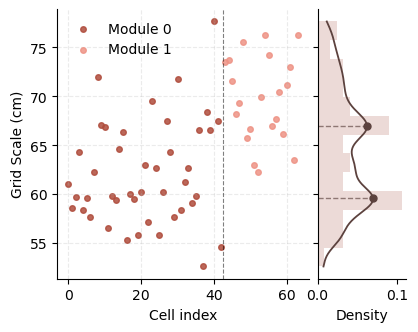

In [43]:
out = plot_run_scales_scatter_hist_kde(
    dt, n_cells=64,
    prominence=0.01,
    grid_size=500,
    bw_mode="exp",
    exp_bw_a=0.4,
    exp_bw_b=0.01,
    exp_bw_min=0.02,
    exp_bw_max=1.0,
)


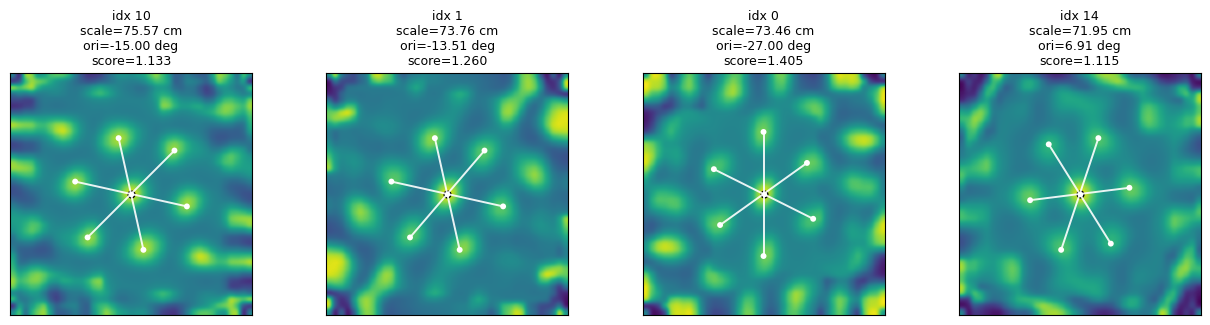

In [20]:
from src.evaluation import (
    plot_sac_examples_with_scale_orientation,
    plot_grid_map_examples_with_scale_orientation,
)

fig, axes = plot_sac_examples_with_scale_orientation(
    sacs=sacs,
    scales_cm=scales_cm,
    orientations_deg=orientations_deg,
    scores=scores,
    n_examples=4,
    selection="largest",  # "first", "largest"/"highest", "smallest"/"lowest"
    draw_peak_connections=True,
    n_peaks=6,
)


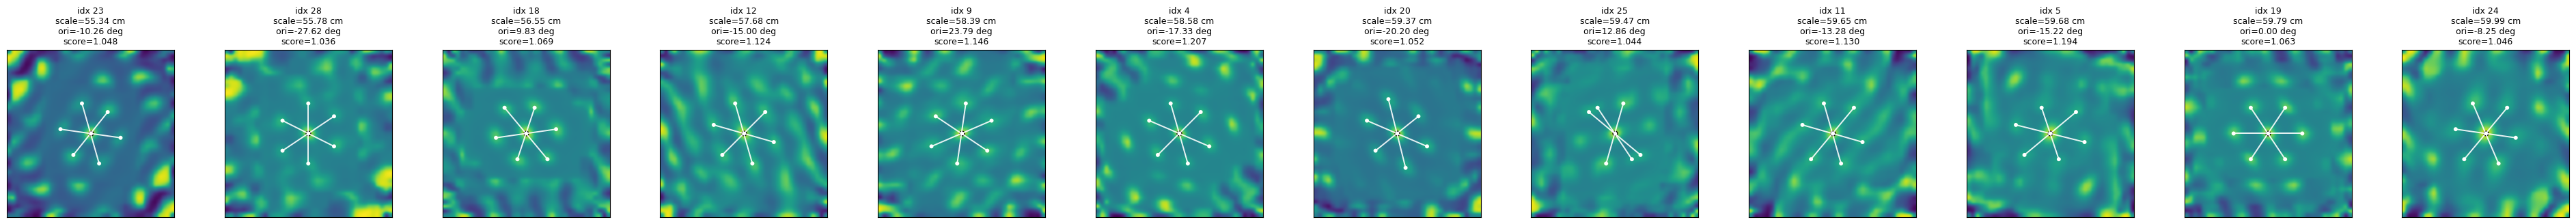

In [21]:
fig, axes = plot_sac_examples_with_scale_orientation(
    sacs=sacs,
    scales_cm=scales_cm,
    orientations_deg=orientations_deg,
    scores=scores,
    n_examples=12,
    selection="smallest",
    draw_peak_connections=True,
)


In [35]:
import numpy as np
import matplotlib.pyplot as plt
from src.visualize import find_global_maxima, find_local_maxima

module_idx_sorted, cfg = module_index_by_sorted_score(run_path)

def plot_sac_indices_local(
    sacs,
    scales_cm,
    module_idx_sorted,
    indices=(0, 1, 2),
    draw_connections=True,
    n_peaks=6,
    cmap="viridis",
    connection_color="white",
    center_color="white",
    peak_color="white",
    line_width=1.4,
    center_size=28,
    peak_size=18,
    title_fontsize=9,
    interpolation="gaussian",
    figsize_per_cell=3.2,
):
    """
    Local notebook helper for plotting selected SACs by explicit score-sorted indices.
    """

    def nearest_ring_peaks(center_peak, local_peaks, n_peaks=6):
        c = np.asarray(center_peak, dtype=float)
        ring = [
            np.asarray(p, dtype=float)
            for p in local_peaks
            if not np.array_equal(np.asarray(p), c)
        ]
        ring = sorted(ring, key=lambda p: np.linalg.norm(p - c))
        return ring[: int(n_peaks)]

    indices = np.asarray(indices, dtype=int)
    n = len(indices)

    fig, axes = plt.subplots(
        1,
        n,
        figsize=(figsize_per_cell * n, figsize_per_cell),
        squeeze=False,
    )
    axes = axes[0]

    for ax, i in zip(axes, indices):
        sac = sacs[i]
        ax.imshow(sac, cmap=cmap, interpolation=interpolation)

        if draw_connections:
            center = np.asarray(find_global_maxima(sac), dtype=float)

            try:
                peaks = nearest_ring_peaks(
                    center,
                    find_local_maxima(sac),
                    n_peaks=n_peaks,
                )

                ax.scatter(
                    center[1],
                    center[0],
                    s=center_size,
                    c=center_color,
                    edgecolors="black",
                    linewidths=0.6,
                    zorder=3,
                )

                for peak in peaks:
                    ax.plot(
                        [center[1], peak[1]],
                        [center[0], peak[0]],
                        color=connection_color,
                        lw=line_width,
                        alpha=0.9,
                        zorder=2,
                        linestyle=":"
                    )
                    ax.scatter(
                        peak[1],
                        peak[0],
                        s=peak_size,
                        c=peak_color,
                        edgecolors="none",
                        zorder=3,
                    )
            except RuntimeError:
                pass

        ax.set_title(
            f"Module {module_idx_sorted[i]} | {scales_cm[i]:.1f} cm",
            fontsize=title_fontsize,
        )

        # ax.set_title(title, fontsize=title_fontsize)
        ax.set_xticks([])
        ax.set_yticks([])

    fig.tight_layout()
    fig.savefig(FIG_DIR / "module_SAC_examples.pdf", bbox_inches="tight")
    return fig, axes


In [36]:
def plot_grid_maps_indices_local(
    rate_maps,
    scales_cm,
    module_idx_sorted,
    indices=(0, 1, 2),
    cmap="jet",
    title_fontsize=9,
    interpolation="bilinear",
    figsize_per_cell=3.2,
):
    """
    Plot selected grid rate maps by explicit score-sorted indices.
    Similar to plot_sac_indices_local but for rate maps (no peak connections).
    """

    indices = np.asarray(indices, dtype=int)
    n = len(indices)

    fig, axes = plt.subplots(
        1,
        n,
        figsize=(figsize_per_cell * n, figsize_per_cell),
        squeeze=False,
    )
    axes = axes[0]

    for ax, i in zip(axes, indices):
        rate_map = rate_maps[i]
        ax.imshow(rate_map, cmap=cmap, interpolation=interpolation)

        ax.set_title(
            f"Module {module_idx_sorted[i]} | {scales_cm[i]:.1f} cm",
            fontsize=title_fontsize,
        )

        ax.set_xticks([])
        ax.set_yticks([])

    fig.tight_layout()
    fig.savefig(FIG_DIR / "module_rate_maps_examples.pdf", bbox_inches="tight")
    return fig, axes

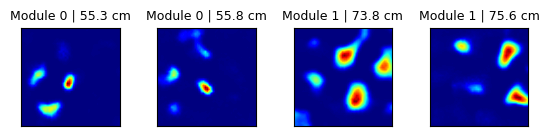

In [40]:

fig, axes = plot_grid_maps_indices_local(
    rate_maps=rate_maps,
    scales_cm=scales_cm,
    module_idx_sorted=module_idx_sorted,
    indices=[23, 28, 1, 10],
    cmap="jet",
    figsize_per_cell=1.4,
    interpolation="bilinear"
)

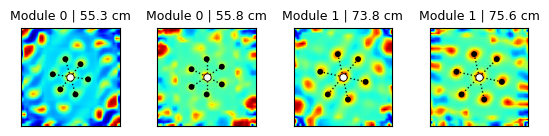

In [39]:
fig, axes = plot_sac_indices_local(
    sacs=sacs,
    scales_cm=scales_cm,
    module_idx_sorted=module_idx_sorted,
    indices=[23, 28, 1, 10],
    draw_connections=True,
    n_peaks=6,
    cmap="jet",
    connection_color="k",
    peak_color="k",
    center_color="white",
    line_width=1.,
    figsize_per_cell=1.4,
    interpolation="bilinear"
)


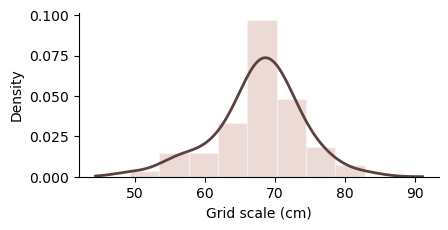

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

ref_dt = "Mar-15-2026-23-02-50"
n_cells = 64

ref_scales_cm, _, ref_scores, _, _ = get_grid_scales_cm(
    ref_dt,
    model="tpc",
    n_cells=n_cells,
)

ref_scales = ref_scales_cm[np.isfinite(ref_scales_cm) & (ref_scales_cm > 0)]

kde = gaussian_kde(ref_scales, bw_method="scott")
x_grid = np.linspace(ref_scales.min() * 0.9, ref_scales.max() * 1.1, 500)

fig, ax = plt.subplots(figsize=(4.5, 2.4))

ax.hist(
    ref_scales,
    bins=8,
    density=True,
    alpha=0.35,
    color="#c9958d",
    edgecolor="white",
    label="tPCN",
)

ax.plot(
    x_grid,
    kde(x_grid),
    color="#5c423e",
    lw=2,
    label="KDE",
)

ax.set_xlabel("Grid scale (cm)")
ax.set_ylabel("Density")
# ax.set_title(ref_dt)
# ax.legend(frameon=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(FIG_DIR / "module_scale_hist_kde.pdf", bbox_inches="tight")
plt.show()


In [50]:
run_path, dt

('../results/tpc/Apr-05-2026-21-45-46', 'Apr-05-2026-21-45-46')

In [51]:
from sklearn.mixture import GaussianMixture
from src.evaluation.module_eval import get_grid_scales_cm

n_cells_list = np.arange(32, 256, 16)
n_perm = 3000
rng = np.random.default_rng(0)

module_idx_sorted, cfg = module_index_by_sorted_score(run_path)

def between_within_ratio(x, labels):
    labels = np.asarray(labels)
    grand = np.mean(x)

    ss_between = 0.0
    ss_within = 0.0

    for lab in np.unique(labels):
        group = x[labels == lab]
        if len(group) == 0:
            continue
        ss_between += len(group) * (np.mean(group) - grand) ** 2
        ss_within += np.sum((group - np.mean(group)) ** 2)

    return ss_between / (ss_within + 1e-12)

obs_vals = []
p_vals = []
null_lo = []
null_hi = []
null_med = []

for n_cells in n_cells_list:
    scales_cm, _, scores, unsrt_scores, sacs = get_grid_scales_cm(
        dt,
        model=model,
        n_cells=int(n_cells),
    )

    mods = module_idx_sorted[: int(n_cells)]
    scales = np.asarray(scales_cm, dtype=float)

    valid = np.isfinite(scales) & (scales > 0)
    x = np.log(scales[valid])
    m = mods[valid]

    obs = between_within_ratio(x, m)

    null = np.empty(n_perm)
    for i in range(n_perm):
        null[i] = between_within_ratio(x, rng.permutation(m))

    p = (np.sum(null >= obs) + 1) / (n_perm + 1)

    obs_vals.append(obs)
    p_vals.append(p)
    null_lo.append(np.percentile(null, 2.5))
    null_med.append(np.percentile(null, 50))
    null_hi.append(np.percentile(null, 97.5))

obs_vals = np.asarray(obs_vals)
p_vals = np.asarray(p_vals)
null_lo = np.asarray(null_lo)
null_med = np.asarray(null_med)
null_hi = np.asarray(null_hi)

In [52]:
print(p_vals)

[0.00033322 0.00033322 0.00033322 0.00033322 0.00033322 0.00033322
 0.00033322 0.00033322 0.00033322 0.00033322 0.00033322 0.00033322
 0.00033322 0.00033322]


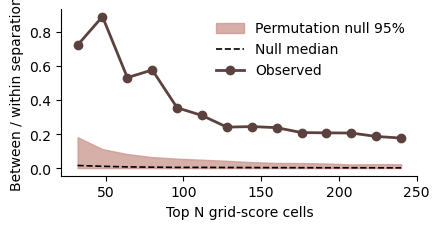

In [53]:
fig, ax = plt.subplots(figsize=(4.5, 2.4))

ax.fill_between(
    n_cells_list,
    null_lo,
    null_hi,
    color="#c9958d",
    alpha=0.75,
    label="Permutation null 95%",
)

ax.plot(
    n_cells_list,
    null_med,
    color="k",
    lw=1.2,
    ls="--",
    label="Null median",
)

ax.plot(
    n_cells_list,
    obs_vals,
    color="#5c423e",
    marker="o",
    lw=2,
    label="Observed",
)

ax.set_xlabel("Top N grid-score cells")
ax.set_ylabel("Between / within separation")
ax.legend(frameon=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(FIG_DIR / "module_between_within_ratio.pdf", bbox_inches="tight")
plt.show()


In [12]:
def plot_run_orientations_scatter_hist_kde(
    dt,
    model="tpc",
    n_cells=64,
    k_max=6,
    prominence=0.15,
    grid_size=500,
    bw_mode="exp",
    exp_bw_a=0.5,
    exp_bw_b=0.01,
    exp_bw_min=0.02,
    exp_bw_max=1.0,
):
    import json
    import numpy as np
    import matplotlib.pyplot as plt
    from src.evaluation.module_eval import (
        estimate_k_from_ksd,
        get_grid_orientations_deg,
    )

    path = f"../results/{model}/{dt}"

    # orientations/scores in sorted-by-score order
    ori_deg, _, scores, unsrt_scores, _ = get_grid_orientations_deg(
        dt, model=model, n_cells=n_cells
    )

    # module ids in sorted-by-score order
    cfg = json.load(open(f"{path}/configs.json", "r"))
    Ng = int(cfg["Ng"])
    n_module = int(cfg.get("n_module", 1))
    fracs = cfg.get("module_fracs", None)

    if fracs is None:
        counts = [Ng // n_module] * n_module
        counts[-1] = Ng - sum(counts[:-1])
    else:
        fr = np.asarray(fracs, dtype=float)
        fr = fr / fr.sum()
        counts = np.floor(fr * Ng).astype(int)
        counts[-1] = Ng - counts[:-1].sum()
        counts = counts.tolist()

    sort_idx = np.argsort(unsrt_scores)[::-1]
    module_of_orig = np.empty(Ng, dtype=int)
    s = 0
    for m, c in enumerate(counts):
        module_of_orig[s:s + c] = m
        s += c
    module_idx_sorted = module_of_orig[sort_idx][:n_cells]

    # keep valid orientations
    valid = np.isfinite(ori_deg)
    ori = ori_deg[valid]
    mods = module_idx_sorted[valid]
    scs = scores[:n_cells][valid]

    # reorder x-axis by module, then by score within module
    order = np.lexsort((-scs, mods))
    ori_o = ori[order]
    mods_o = mods[order]
    x_o = np.arange(len(ori_o))

    # KDE/peaks on orientation values directly
    k_est, ksd = estimate_k_from_ksd(
        ori_o,
        k_max=k_max,
        prominence=prominence,
        grid_size=grid_size,
        bw_mode=bw_mode,
        exp_bw_a=exp_bw_a,
        exp_bw_b=exp_bw_b,
        exp_bw_min=exp_bw_min,
        exp_bw_max=exp_bw_max,
    )
    peak_deg = ksd["grid"][ksd["peaks"]]
    peak_dens = ksd["density"][ksd["peaks"]]

    # plot
    fig = plt.figure(figsize=(6, 4))
    gs = fig.add_gridspec(1, 2, width_ratios=[4, 1.4], wspace=0.05)
    ax_sc = fig.add_subplot(gs[0, 0])
    ax_hi = fig.add_subplot(gs[0, 1], sharey=ax_sc)

    cmap = plt.cm.get_cmap("tab20", max(2, n_module))
    for m in np.unique(mods_o):
        msk = mods_o == m
        ax_sc.scatter(x_o[msk], ori_o[msk], s=16, alpha=0.85, color=cmap(int(m)), label=f"M{int(m)}")

    boundaries = np.where(np.diff(mods_o) != 0)[0]
    for b in boundaries:
        ax_sc.axvline(b + 0.5, color="k", ls="--", lw=0.8, alpha=0.5)

    ax_sc.set_xlabel("Cell index")
    ax_sc.set_ylabel("Grid Orientation (deg)")
    ax_sc.legend(frameon=False, loc="best")
    ax_sc.grid(True, which="major", axis="both", alpha=0.25, linestyle="--")

    # rotated histogram + KDE (on orientation axis)
    ax_hi.hist(ori_o, bins=13, orientation="horizontal", density=True, alpha=0.35, color="gray")
    ax_hi.plot(ksd["density"], ksd["grid"], color="black", lw=2)

    for p_deg, d_pk in zip(peak_deg, peak_dens):
        ax_hi.axhline(p_deg, color="crimson", ls="--", lw=1, alpha=0.6)
        ax_hi.plot(d_pk, p_deg, "o", color="crimson", ms=5)

    ax_hi.set_xlabel("Density")
    plt.setp(ax_hi.get_yticklabels(), visible=False)

    for ax in [ax_sc, ax_hi]:
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()

    return {
        "k_est": k_est,
        "peaks_deg": peak_deg,
        "ordered_orientations_deg": ori_o,
        "ordered_modules": mods_o,
        "ksd": ksd,
    }


C:\Users\User\AppData\Local\Temp\ipykernel_18688\3452569097.py:86: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap("tab20", max(2, n_module))
C:\Users\User\AppData\Local\Temp\ipykernel_18688\3452569097.py:115: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


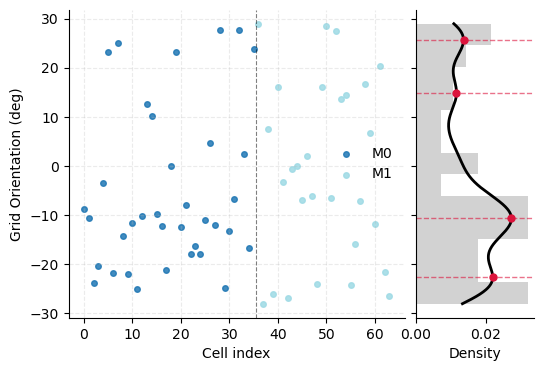

In [13]:
_ = plot_run_orientations_scatter_hist_kde(
    "Apr-05-2026-23-13-47", n_cells=64,
    prominence=0.05,
    grid_size=500,
    bw_mode="exp",
    exp_bw_a=0.4,
    exp_bw_b=0.01,
    exp_bw_min=0.02,
    exp_bw_max=1.0,
)

C:\Users\User\AppData\Local\Temp\ipykernel_18688\2307887597.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap("tab10", max(2, int(cfg.get("n_module", 1))))


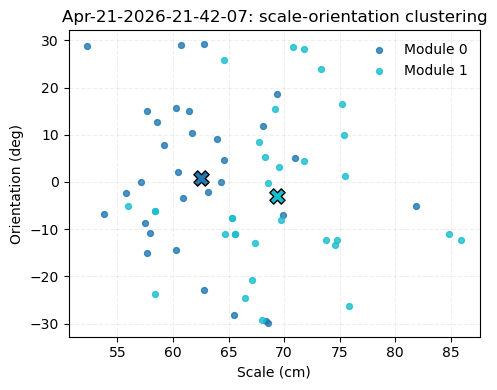

In [14]:
# 2D clustering view: x=scale, y=orientation, colored by module
valid = np.isfinite(scales_cm) & np.isfinite(orientations_deg)
x = scales_cm[valid]
y = orientations_deg[valid]
m = module_idx_sorted[:len(scales_cm)][valid]

plt.figure(figsize=(5, 4))
cmap = plt.cm.get_cmap("tab10", max(2, int(cfg.get("n_module", 1))))

for mod in np.unique(m):
    mk = m == mod
    plt.scatter(x[mk], y[mk], s=18, alpha=0.8, color=cmap(int(mod)), label=f"Module {int(mod)}")

# module centroids
for mod in np.unique(m):
    mk = m == mod
    cx, cy = np.mean(x[mk]), np.mean(y[mk])
    plt.scatter(cx, cy, s=120, marker="X", edgecolor="black", linewidth=1, color=cmap(int(mod)))

plt.xlabel("Scale (cm)")
plt.ylabel("Orientation (deg)")
plt.title(f"{dt}: scale-orientation clustering")
plt.grid(alpha=0.2, linestyle="--")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


In [15]:
def plot_run_orientations_scatter_hists(
    dt,
    model="tpc",
    n_cells=64,
    bins=13,
):
    import json
    import numpy as np
    import matplotlib.pyplot as plt
    from src.evaluation.module_eval import get_grid_orientations_deg

    path = f"../results/{model}/{dt}"

    # orientations/scores in sorted-by-score order
    ori_deg, _, scores, unsrt_scores, _ = get_grid_orientations_deg(
        dt, model=model, n_cells=n_cells
    )

    # module ids in sorted-by-score order
    cfg = json.load(open(f"{path}/configs.json", "r"))
    Ng = int(cfg["Ng"])
    n_module = int(cfg.get("n_module", 1))
    fracs = cfg.get("module_fracs", None)

    if fracs is None:
        counts = [Ng // n_module] * n_module
        counts[-1] = Ng - sum(counts[:-1])
    else:
        fr = np.asarray(fracs, dtype=float)
        fr = fr / fr.sum()
        counts = np.floor(fr * Ng).astype(int)
        counts[-1] = Ng - counts[:-1].sum()
        counts = counts.tolist()

    sort_idx = np.argsort(unsrt_scores)[::-1]
    module_of_orig = np.empty(Ng, dtype=int)
    s = 0
    for m, c in enumerate(counts):
        module_of_orig[s:s + c] = m
        s += c
    module_idx_sorted = module_of_orig[sort_idx][:n_cells]

    # keep valid orientations
    valid = np.isfinite(ori_deg)
    ori = ori_deg[valid]
    mods = module_idx_sorted[valid]
    scs = scores[:n_cells][valid]

    # reorder x-axis by module, then by score within module
    order = np.lexsort((-scs, mods))
    ori_o = ori[order]
    mods_o = mods[order]
    x_o = np.arange(len(ori_o))

    # colors
    module_colors = {0: "#1F77B4", 1: "#FF7F0E"}

    # layout: scatter + 3 histogram panels (overall, M0, M1)
    fig = plt.figure(figsize=(9, 4))
    gs = fig.add_gridspec(1, 4, width_ratios=[4, 1., 1., 1.], wspace=0.12)

    ax_sc = fig.add_subplot(gs[0, 0])
    ax_all = fig.add_subplot(gs[0, 1], sharey=ax_sc)
    ax_m0 = fig.add_subplot(gs[0, 2], sharey=ax_sc)
    ax_m1 = fig.add_subplot(gs[0, 3], sharey=ax_sc)

    # scatter by module
    for m in np.unique(mods_o):
        m = int(m)
        msk = mods_o == m
        color = module_colors.get(m, f"C{m}")
        ax_sc.scatter(
            x_o[msk], ori_o[msk], s=16, alpha=0.85,
            color=color, label=f"M{m}"
        )

    boundaries = np.where(np.diff(mods_o) != 0)[0]
    for b in boundaries:
        ax_sc.axvline(b + 0.5, color="k", ls="--", lw=0.8, alpha=0.5)

    ax_sc.set_xlabel("Cell index")
    ax_sc.set_ylabel("Grid Orientation (deg)")
    ax_sc.legend(frameon=False, loc="best")
    ax_sc.grid(True, which="major", axis="both", alpha=0.25, linestyle="--")

    # overall histogram
    ax_all.hist(
        ori_o, bins=bins, orientation="horizontal", density=True,
        alpha=0.5, color="gray", edgecolor="white", linewidth=0.8
    )
    ax_all.set_title("Overall", fontsize=10)
    ax_all.set_xlabel("Density")
    plt.setp(ax_all.get_yticklabels(), visible=False)

    # module 0 histogram
    m0 = ori_o[mods_o == 0]
    if len(m0) > 0:
        ax_m0.hist(
            m0, bins=bins, orientation="horizontal", density=True,
            alpha=0.5, color=module_colors[0], edgecolor="white", linewidth=0.8
        )
    ax_m0.set_title(f"Module 0 (n={len(m0)})", fontsize=10)
    ax_m0.set_xlabel("Density")
    plt.setp(ax_m0.get_yticklabels(), visible=False)

    # module 1 histogram
    m1 = ori_o[mods_o == 1]
    if len(m1) > 0:
        ax_m1.hist(
            m1, bins=bins, orientation="horizontal", density=True,
            alpha=0.5, color=module_colors[1], edgecolor="white", linewidth=0.8
        )
    ax_m1.set_title(f"Module 1 (n={len(m1)})", fontsize=10)
    ax_m1.set_xlabel("Density")
    plt.setp(ax_m1.get_yticklabels(), visible=False)

    for ax in [ax_sc, ax_all, ax_m0, ax_m1]:
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()

    return {
        "ordered_orientations_deg": ori_o,
        "ordered_modules": mods_o,
        "module0_orientations": m0,
        "module1_orientations": m1,
    }


C:\Users\User\AppData\Local\Temp\ipykernel_18688\3437276186.py:121: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


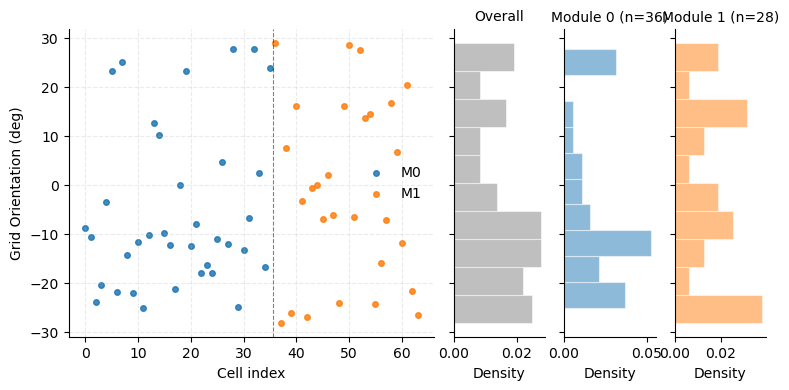

In [16]:
out = plot_run_orientations_scatter_hists(
    dt="Apr-05-2026-23-13-47",
    model="tpc",
    n_cells=64,
    bins=10,
)


In [150]:
def circ_mean_deg_pm30(x):
    th = np.deg2rad(x * 6.0)     # map 60-deg periodicity to full circle
    z = np.exp(1j * th).mean()
    return np.rad2deg(np.angle(z)) / 6.0  # back to [-30,30]

def perm_test_circ_mean_diff(x0, x1, n_perm=10000, seed=0):
    rng = np.random.default_rng(seed)
    obs = abs(circ_mean_deg_pm30(x0) - circ_mean_deg_pm30(x1))

    x = np.concatenate([x0, x1])
    n0 = len(x0)
    cnt = 0
    for _ in range(n_perm):
        rng.shuffle(x)
        d = abs(circ_mean_deg_pm30(x[:n0]) - circ_mean_deg_pm30(x[n0:]))
        cnt += (d >= obs)
    p = (cnt + 1) / (n_perm + 1)
    return obs, p

obs, p_perm = perm_test_circ_mean_diff(x0, x1)
print(f"Permutation |Δ circular mean| = {obs:.3f} deg, p-value = {p_perm:.3e}")


Permutation |Δ circular mean| = 31.086 deg, p-value = 1.820e-02
